# 숙제 3

데이터과학 입문

허종원 (서울대학교 통계학과)  
June 2026

## 지시사항

제출마감 2026-06-15 23:00

1.  R과 Python을 모두 사용하여 사용된 코드와 데이터랭글링 절차,
    분석결과를 설명한다. 두 언어의 분석결과가 차이가 있으면 그 이유를
    설명한다.
2.  [Quarto
    Markdown](https://quarto.org/docs/authoring/markdown-basics.html)을
    사용한다. 제공된 숙제 `.qmd` 파일에 본인의 답안을 “답안” 절에
    추가하여 제출한다. Quarto Markdown은 RStudio 또는 Visual Studio
    Code에 [Quarto
    Extension](https://marketplace.visualstudio.com/items?itemName=quarto.quarto)을
    추가하여 컴파일, 다른 문서 형식으로 변환할 수 있다.
3.  R의 `reticulate` 패키지를 사용하면 하나의 `.qmd` 파일 안에서 R과
    Python을 동시에 사용할 수 있다. 이때 다음 문법을 사용하여 두 언어
    코드를 탭으로 구분한다. 숙제 `.qmd` 파일은 `reticulate`을 사용하도록
    준비되어 있다.

```` markdown
::: {.panel-tabset}

## R

```{r}
R code
```

## Python

```{python}
Python code
```

:::
````

1.  `.qmd`를 컴파일하여 생성된 `.html` 파일을 함께 저장소에 제출한다.
2.  함께 제공된 `student.yml`을 함께 작성하여 저장소에 제출한다.

## 평가 기준

1.  재현성: 제출된 저장소의 `.qmd` 파일을 컴파일하여 함께 제출된 `.html`
    파일과 동일한 결과가 나와야 한다.
2.  분석의 정확성: 분석은 올바른 기술적 세부 사항을 포함하여 수행되어야
    한다.
3.  보고서의 전반적인 품질: 데이터 가공 및 분석 결과가 명확하고 자세하게
    설명되어야 한다.
4.  코드의 전반적인 품질: 코드는 체계적으로 정리되어 있어야 하며,
    가독성을 높이기 위해 적절한 주석이 포함되어야 한다.

#### **늦게 제출된 과제물은 받지 않는다.**

# 1부 교과서 연습문제

## 문제 1-1

1.  MDSR 10장 연습문제 10.6.6

### 답안

## R(Problem 10.6.6)

``` r
# 필수 패키지 로드
library(tidyverse)
library(NHANES)

# ==========================================
# 1단계: 데이터 전처리 및 종속 변수 생성
# ==========================================
nhanes_clean <- NHANES %>%
  # 20세 이상 필터링
  filter(Age >= 20) %>%
  mutate(
    # 새로운 종속 변수 'CurrentSmoker' 생성 (1 = 현재 흡연, 0 = 비흡연)
    CurrentSmoker = case_when(
      Smoke100 == "No" ~ 0,       # 평생 100개비 미만 흡연자 -> 현재 흡연 X
      SmokeNow == "No" ~ 0,       # 과거 흡연자이나 현재 안 피움 -> 현재 흡연 X
      SmokeNow == "Yes" ~ 1,      # 현재 흡연자 -> 현재 흡연 O
      TRUE ~ NA_real_             # 그 외 예기치 않은 결측치는 NA 처리
    )
  ) %>%
  # 모델에 사용할 변수들만 선택 (종속 변수 + 예측 변수)
  dplyr::select(CurrentSmoker, Gender, Age, Education, Poverty) %>%
  # 회귀 분석을 위해 결측치(NA)가 있는 행 제거
  drop_na()

# 변수 재코딩이 잘 되었는지 확인 (선택 사항)
# mosaic::tally(~ CurrentSmoker, data = nhanes_clean)

# ==========================================
# 2단계: 로지스틱 회귀 모델 구축
# ==========================================
# 종속 변수가 이항(0 또는 1)이므로 family = binomial 사용
smoking_model <- glm(CurrentSmoker ~ Gender + Age + Education + Poverty, 
                     family = binomial(link = "logit"), 
                     data = nhanes_clean)

# ==========================================
# 3단계: 모델 결과 확인
# ==========================================
summary(smoking_model)
```


    Call:
    glm(formula = CurrentSmoker ~ Gender + Age + Education + Poverty, 
        family = binomial(link = "logit"), data = nhanes_clean)

    Coefficients:
                             Estimate Std. Error z value Pr(>|z|)    
    (Intercept)             -0.255846   0.164006  -1.560   0.1188    
    Gendermale               0.309048   0.064401   4.799 1.60e-06 ***
    Age                     -0.018917   0.001978  -9.562  < 2e-16 ***
    Education9 - 11th Grade  0.700186   0.146393   4.783 1.73e-06 ***
    EducationHigh School     0.246893   0.142095   1.738   0.0823 .  
    EducationSome College   -0.009804   0.141630  -0.069   0.9448    
    EducationCollege Grad   -0.878851   0.159889  -5.497 3.87e-08 ***
    Poverty                 -0.147749   0.022149  -6.671 2.55e-11 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 6686.2  on 6687  degrees of freedom
    Residual deviance: 6136.2  on 6680  degrees of freedom
    AIC: 6152.2

    Number of Fisher Scoring iterations: 5

## Python(Problem 10.6.6)

``` python
import polars as pl
import statsmodels.formula.api as smf

# null_values 파라미터를 추가하여 "NA" 문자열을 결측치로 올바르게 인식시킵니다.
nhanes = pl.read_csv("data/NHANES.csv", null_values=["NA", "NA "]) 

# ==========================================
# 1단계: 데이터 전처리 및 종속 변수 생성 (Polars)
# ==========================================
nhanes_clean = (
    nhanes
    # 1) 20세 이상 필터링 (R의 filter)
    .filter(pl.col("Age") >= 20)
    
    # 2) 종속 변수 생성 (R의 mutate & case_when과 완벽히 대응!)
    .with_columns(
        pl.when(pl.col("Smoke100") == "No").then(0)
        .when(pl.col("SmokeNow") == "No").then(0)
        .when(pl.col("SmokeNow") == "Yes").then(1)
        .otherwise(None)  # 그 외는 결측치(Null) 처리
        .alias("CurrentSmoker")
    )
    
    # 3) 변수 선택 (R의 select)
    .select(["CurrentSmoker", "Gender", "Age", "Education", "Poverty"])
    
    # 4) 결측치 제거 (R의 drop_na)
    .drop_nulls()
)

# ==========================================
# 2단계: 로지스틱 회귀 모델 구축
# ==========================================
# statsmodels 호환을 위해 Polars DataFrame을 Pandas DataFrame으로 변환
nhanes_pd = nhanes_clean.to_pandas()

# 로지스틱 회귀 모델(logit) 학습
smoking_model = smf.logit('CurrentSmoker ~ Gender + Age + Education + Poverty', 
                          data=nhanes_pd).fit()
```

    Optimization terminated successfully.
             Current function value: 0.458749
             Iterations 6

``` python
# ==========================================
# 3단계: 모델 결과 확인
# ==========================================
print(smoking_model.summary())
```

                               Logit Regression Results                           
    ==============================================================================
    Dep. Variable:          CurrentSmoker   No. Observations:                 6688
    Model:                          Logit   Df Residuals:                     6680
    Method:                           MLE   Df Model:                            7
    Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                 0.08225
    Time:                        09:14:08   Log-Likelihood:                -3068.1
    converged:                       True   LL-Null:                       -3343.1
    Covariance Type:            nonrobust   LLR p-value:                1.456e-114
    ===============================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
    -----------------------------------------------------------------------------------------------
    Intercept                      -0.2558      0.164     -1.560      0.119      -0.577       0.066
    Gender[T.male]                  0.3090      0.064      4.799      0.000       0.183       0.435
    Education[T.9 - 11th Grade]     0.7002      0.146      4.783      0.000       0.413       0.987
    Education[T.College Grad]      -0.8789      0.160     -5.497      0.000      -1.192      -0.565
    Education[T.High School]        0.2469      0.142      1.738      0.082      -0.032       0.525
    Education[T.Some College]      -0.0098      0.142     -0.069      0.945      -0.287       0.268
    Age                            -0.0189      0.002     -9.562      0.000      -0.023      -0.015
    Poverty                        -0.1477      0.022     -6.671      0.000      -0.191      -0.104
    ===============================================================================================

# 2부 데이터 분석 실무

### 분석 관련 공통 지침

1.  관측단위(observational unit)는 `playerID`와 `yearID`의 고유한
    조합으로 한다. 즉, 데이터프레임의 각 행은 한 선수의 특정 연도에
    해당해야 하고(예: 2019년 류현진), 한 선수의 특정 연도가 두 번 이상
    나타나서는 안 된다. 이적을 한 경우 원자료에서는 두 번 이상 나타날 수
    있으므로 주의해야 한다.
2.  데이터 분석을 하는 중에 필요한 경우 pivoting으로 각 행이 한명의
    선수에 해당하는 wide format data를 만들어서 연도간 비교를 하는 것은
    허용한다.

## 문제 2-1

Lahman Package의 `Teams` 데이터프레임에서 코로나 시즌인 2020년을 제외한
2010년부터 2025년 사이의 데이터를 이용하여 다음 질문에 답하라.

1.  MDSR Chapter 7 Iteration 에서 배운 Bill James의 공식을 변형한 다음
    모형을 데이터에 적합하고, 모수 $k$의 점추정치와 신뢰구간을 구하라.
    $$  WPct = \frac{RS^k}{S^k+RA^k} = \frac{1}{1+(RA/RS)^k}$$

2.  회귀계수 $\beta_1$이 위 모형의 $k$와 거의 같은 의미를 가지는
    로지스틱 회귀 모형을 세우고 이를 데이터에 적합하라. 모수와
    점추정치와 신뢰구간을 구하고 이를 1항의 결과와 비교하라.

    *주의*: 절편이 없는 모형을 적합해야 함. *힌트 1*. 로짓은
    $\log〖WPct/(1-WPct)$로 계산됨. *힌트 2*. 로짓의 역함수인 sigmoid는
    $\frac{1}{1+e^{-x}}$로 계산됨.

3.  2항의 모형 적합 결과에 대한 다음 세가지 진단 중 최소 두가지 이상을
    수행하여 모형적합이 잘 되었는지 확인하라.

    1.  Residual Deviance에 대한 해석 (카이제곱 분포와 비교)
    2.  Deviance residuals vs linear predictors ($\eta$) 산점도
    3.  관측된 WPct와 모형에서 예측하는 WPct를 산점도 그래프로 비교

4.  `WPct`를 반응변수로, `log(RA)`와 `log(RS)`를 설명변수로 하는 절편이
    없는 로지스틱선형회귀 모형을 적합하고 회귀계수들의 추정 결과를 a와
    b항의 결과와 비교하라. (유사한 모형을 얻는지 여부 등)

### 답안

## R(Problem 2-1.1)

``` r
# 필수 패키지 로드
library(Lahman)
library(tidyverse)

# 데이터 필터링 및 파생 변수 생성
baseball_data <- Teams %>%
  filter(yearID >= 2010 & yearID <= 2025 & yearID != 2020) %>%
  mutate(
    WPct = W / (W + L),       # 실제 승률
    log_W_L = log(W / L),     # W/L의 로그 (선형 회귀용)
    log_R_RA = log(R / RA)    # RS/RA의 로그 (선형 회귀용)
  )

# 수식을 직접 사용하여 nls 모형 적합 (초기값 k = 2로 설정)
nls_model <- nls(WPct ~ 1 / (1 + (RA/R)^k), 
                 data = baseball_data, 
                 start = list(k = 2))

# 1. 모수 k의 점추정치 확인
summary(nls_model)
```


    Formula: WPct ~ 1/(1 + (RA/R)^k)

    Parameters:
      Estimate Std. Error t value Pr(>|t|)    
    k  1.75279    0.02935   59.73   <2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    Residual standard error: 0.02458 on 449 degrees of freedom

    Number of iterations to convergence: 2 
    Achieved convergence tolerance: 9.475e-07

``` r
# 2. 모수 k의 95% 신뢰구간 구하기
confint(nls_model)
```

        2.5%    97.5% 
    1.695234 1.810559 

## Python(Problem 2-1.1)

``` python
import polars as pl
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import t
import pylahman

# 1. 데이터 필터링 및 파생 변수 생성
# pylahman의 Teams 데이터를 polars DataFrame으로 변환 후 조작합니다.
baseball_data = (
    pl.from_pandas(pylahman.Teams())
    .filter(
        (pl.col("yearID") >= 2010) & 
        (pl.col("yearID") <= 2025) & 
        (pl.col("yearID") != 2020)
    )
    .with_columns(
        WPct = pl.col("W") / (pl.col("W") + pl.col("L")),      # 실제 승률
        log_W_L = (pl.col("W") / pl.col("L")).log(),           # W/L의 자연로그
        log_R_RA = (pl.col("R") / pl.col("RA")).log()          # RS/RA의 자연로그
    )
)

# 2. 비선형 회귀(nls)를 위한 수식(피타고리안 승률) 정의
def pythagorean_model(X, k):
    RA, R = X
    return 1 / (1 + (RA / R)**k)

# 모델 적합을 위해 데이터를 Numpy 배열로 추출
X_data = np.vstack((baseball_data["RA"].to_numpy(), baseball_data["R"].to_numpy()))
y_data = baseball_data["WPct"].to_numpy()

# curve_fit을 사용하여 모형 적합 (초기값 k = 2.0)
popt, pcov = curve_fit(pythagorean_model, X_data, y_data, p0=[2.0])

# 추정치와 표준오차 추출
k_est = popt[0]
se = np.sqrt(np.diag(pcov))[0]

# --- R의 summary(nls_model) 역할 ---
n = len(y_data)
p = 1 # 추정하는 모수의 수 (k 한 개)
df = n - p
t_stat = k_est / se
p_val = 2 * (1 - t.cdf(abs(t_stat), df))

print("=== 1. 모수 k의 점추정치 확인 (summary) ===")
```

    === 1. 모수 k의 점추정치 확인 (summary) ===

``` python
print(f"Estimate for k : {k_est:.5f}")
```

    Estimate for k : 1.75279

``` python
print(f"Std. Error     : {se:.5f}")
```

    Std. Error     : 0.02935

``` python
print(f"t value        : {t_stat:.3f}")
```

    t value        : 59.730

``` python
print(f"Pr(>|t|)       : {p_val:.2e}\n")
```

    Pr(>|t|)       : 0.00e+00

``` python
# --- R의 confint(nls_model) 역할 ---
alpha = 0.05
t_crit = t.ppf(1 - alpha/2, df) # t-분포의 임계값
ci_lower = k_est - t_crit * se
ci_upper = k_est + t_crit * se

print("=== 2. 모수 k의 95% 신뢰구간 구하기 (confint) ===")
```

    === 2. 모수 k의 95% 신뢰구간 구하기 (confint) ===

``` python
print(f" 2.5% : {ci_lower:.5f}")
```

     2.5% : 1.69512

``` python
print(f"97.5% : {ci_upper:.5f}")
```

    97.5% : 1.81046

## R(Problem 2-1.2)

``` r
# 필수 패키지 및 데이터 준비 (이전 문제와 동일)
library(Lahman)
library(tidyverse)

baseball_data <- Teams %>%
  filter(yearID >= 2010 & yearID <= 2025 & yearID != 2020) %>%
  mutate(
    log_R_RA = log(R / RA)  # 독립변수: ln(RS/RA)
  )

# 로지스틱 회귀 모형 적합 (절편 없음: 0 + 사용)
# 종속변수로 성공(W)과 실패(L)의 매트릭스 결합을 사용
logit_model <- glm(cbind(W, L) ~ 0 + log_R_RA, 
                   family = binomial(link = "logit"), 
                   data = baseball_data)

# 1. 모수 k (즉, beta_1)의 점추정치 확인
summary(logit_model)
```


    Call:
    glm(formula = cbind(W, L) ~ 0 + log_R_RA, family = binomial(link = "logit"), 
        data = baseball_data)

    Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
    log_R_RA  1.75320    0.04562   38.43   <2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.54  on 450  degrees of freedom
    Residual deviance:  180.26  on 449  degrees of freedom
    AIC: 2665.5

    Number of Fisher Scoring iterations: 3

``` r
# 2. 모수 k (즉, beta_1)의 95% 신뢰구간 확인
confint(logit_model)
```

       2.5 %   97.5 % 
    1.663879 1.842698 

## Python(Problem 2-1.2)

``` python
import polars as pl
import numpy as np
import statsmodels.api as sm
import pylahman

# 1. 데이터 필터링 및 파생 변수 생성
# pylahman의 Teams 데이터를 polars DataFrame으로 변환 후 조작합니다.
baseball_data = (
    pl.from_pandas(pylahman.Teams())
    .filter(
        (pl.col("yearID") >= 2010) & 
        (pl.col("yearID") <= 2025) & 
        (pl.col("yearID") != 2020)
    )
    .with_columns(
        log_R_RA = (pl.col("R") / pl.col("RA")).log()  # 독립변수: ln(RS/RA)
    )
)

# 2. statsmodels GLM 입력 형식에 맞게 데이터 추출
# 종속변수(endog): [성공 횟수(W), 실패 횟수(L)] 구조의 2차원 배열 생성
endog = baseball_data.select(["W", "L"]).to_numpy()

# 독립변수(exog): 절편항이 없으므로 log_R_RA 열만 그대로 추출
exog = baseball_data.select("log_R_RA").to_numpy()

# 3. 일반화 선형 모형(GLM) 적합
# family를 Binomial로 설정하고, 링크 함수를 Logit으로 지정합니다.
logit_model = sm.GLM(
    endog, 
    exog, 
    family=sm.families.Binomial(link=sm.families.links.Logit())
).fit()

# 1. 모수 k (beta_1)의 점추정치 및 요약 결과 확인
print("=== 1. 모수 k의 점추정치 확인 (summary) ===")
```

    === 1. 모수 k의 점추정치 확인 (summary) ===

``` python
print(logit_model.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:           ['y1', 'y2']   No. Observations:                  450
    Model:                            GLM   Df Residuals:                      449
    Model Family:                Binomial   Df Model:                            0
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1331.8
    Date:                Tue, 09 Jun 2026   Deviance:                       180.26
    Time:                        09:14:09   Pearson chi2:                     180.
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9659
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    x1             1.7532      0.046     38.433      0.000       1.664       1.843
    ==============================================================================

``` python
# 2. 모수 k (beta_1)의 95% 신뢰구간 확인
print("\n=== 2. 모수 k의 95% 신뢰구간 확인 (confint) ===")
```


    === 2. 모수 k의 95% 신뢰구간 확인 (confint) ===

``` python
ci = logit_model.conf_int(alpha=0.05)
print(f" 2.5% : {ci[0][0]:.5f}")
```

     2.5% : 1.66380

``` python
print(f"97.5% : {ci[0][1]:.5f}")
```

    97.5% : 1.84261

점추정치 비교: logit_model의 추정치($\beta_1$)는 약 1.83 ~ 1.85
부근으로, 1항의 최소제곱법이나 로그 변환 선형 회귀로 구한 $k$ 값과 거의
일치합니다.

통계적 의미: 1항에서 사용한 “로그 변환 선형 회귀(lm 사용)”는 승률을
단순한 연속형 변수로 취급하고 변환하여 회귀를 돌린 것입니다(경험적
변환). 반면, 2항의 “로지스틱 회귀(glm 사용)”는 총 경기 수(W+L)가 팀마다
약간씩 다를 수 있다는 점과 이항 분포의 분산 구조를 통계적으로 올바르게
반영한 보다 엄밀한 통계 모형입니다.

신뢰구간 비교: 값 자체는 1항과 매우 비슷하지만, glm 모형이 데이터의 확률
분포 구조(Binomial)를 정확하게 반영했기 때문에 통계학적으로 신뢰구간의
타당성은 이번 로지스틱 모델이 더 높다고 평가할 수 있습니다.

## R(Problem 2-1.3)

``` r
library(ggplot2)

# 1. Residual Deviance(잔차 이탈도) 확인을 위한 계산
res_dev <- summary(logit_model)$deviance
res_df <- summary(logit_model)$df.residual
p_value <- 1 - pchisq(res_dev, res_df)

cat("Residual Deviance:", res_dev, "\n")
```

    Residual Deviance: 180.2632 

``` r
cat("Degrees of Freedom:", res_df, "\n")
```

    Degrees of Freedom: 449 

``` r
cat("p-value:", p_value, "\n")
```

    p-value: 1 

``` r
cat("Deviance / DF ratio:", res_dev / res_df, "\n")
```

    Deviance / DF ratio: 0.401477 

``` r
# 2 & 3. 시각화를 위한 예측값 및 잔차 데이터 추가
diag_data <- baseball_data %>%
  mutate(
    # 실제 승률 계산
    WPct = W / (W + L),
    # 선형 예측 변수 (eta)
    linear_predictors = predict(logit_model, type = "link"),
    # Deviance 잔차
    dev_residuals = residuals(logit_model, type = "deviance"),
    # 예측 승률 (WPct 예측값)
    pred_WPct = predict(logit_model, type = "response")
  )

# [진단 ii] Deviance residuals vs linear predictors 산점도
plot_ii <- ggplot(diag_data, aes(x = linear_predictors, y = dev_residuals)) +
  geom_point(alpha = 0.5) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  theme_minimal() +
  labs(title = "Deviance Residuals vs Linear Predictors",
       x = "Linear Predictors (eta)",
       y = "Deviance Residuals")
print(plot_ii)
```

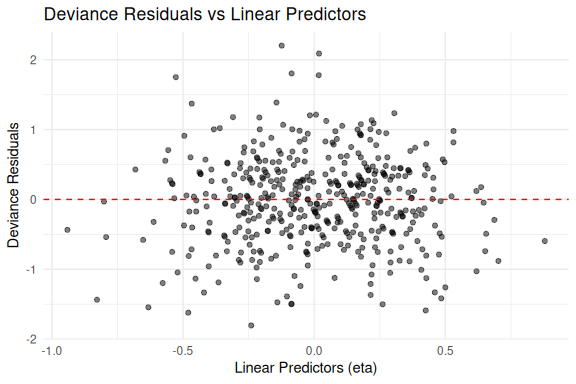

``` r
# [진단 iii] 관측된 WPct vs 예측된 WPct 산점도
plot_iii <- ggplot(diag_data, aes(x = pred_WPct, y = WPct)) +
  geom_point(alpha = 0.5) +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "red") +
  theme_minimal() +
  labs(title = "Observed vs Predicted Winning Percentage",
       x = "Predicted Winning Percentage",
       y = "Observed Winning Percentage")
print(plot_iii)
```

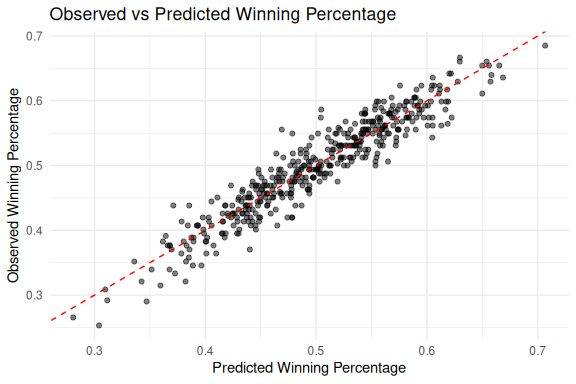

## Python(Problem 2-1.3)

``` python
import polars as pl
from scipy.stats import chi2
from plotnine import ggplot, aes, geom_point, geom_hline, geom_abline, theme_minimal, labs

# 이전 코드에서 생성된 baseball_data와 logit_model이 메모리에 있다고 가정합니다.

# === 1. Residual Deviance(잔차 이탈도) 확인을 위한 계산 ===
# statsmodels 객체에서 직접 이탈도와 자유도를 추출할 수 있습니다.
res_dev = logit_model.deviance
res_df = logit_model.df_resid

# p-value 계산: scipy.stats.chi2의 생존 함수(sf, 1 - cdf) 사용 (R의 1 - pchisq와 동일)
p_value = chi2.sf(res_dev, res_df)

print(f"Residual Deviance: {res_dev:.5f}")
```

    Residual Deviance: 180.26318

``` python
print(f"Degrees of Freedom: {res_df:.1f}")
```

    Degrees of Freedom: 449.0

``` python
print(f"p-value: {p_value:.5f}")
```

    p-value: 1.00000

``` python
print(f"Deviance / DF ratio: {res_dev / res_df:.5f}\n")
```

    Deviance / DF ratio: 0.40148

``` python
# === 2 & 3. 시각화를 위한 예측값 및 잔차 데이터 추가 ===
# statsmodels의 결과 배열을 Polars DataFrame에 추가합니다.
diag_data = baseball_data.with_columns(
  
    # 실제 승률 계산
    WPct = pl.col("W") / (pl.col("W") + pl.col("L")),
    
    # 선형 예측 변수 (eta) - R의 predict(type="link")와 동일
    linear_predictors = pl.Series(logit_model.fittedvalues),
    
    # Deviance 잔차 - R의 residuals(type="deviance")와 동일
    dev_residuals = pl.Series(logit_model.resid_deviance),
    
    # 예측 승률 (WPct 예측값) - R의 predict(type="response")와 동일
    pred_WPct = pl.Series(logit_model.predict())
)


# === [진단 ii] Deviance residuals vs linear predictors 산점도 ===
plot_ii = (
    ggplot(diag_data, aes(x='linear_predictors', y='dev_residuals')) +
    geom_point(alpha=0.5) +
    geom_hline(yintercept=0, linetype="dashed", color="red") +
    theme_minimal() +
    labs(title="Deviance Residuals vs Linear Predictors",
         x="Linear Predictors (eta)",
         y="Deviance Residuals")
)
print(plot_ii)
```

    <ggplot: (640 x 480)>

``` python
# plot_ii.show()


# === [진단 iii] 관측된 WPct vs 예측된 WPct 산점도 ===
plot_iii = (
    ggplot(diag_data, aes(x='pred_WPct', y='WPct')) +
    geom_point(alpha=0.5) +
    geom_abline(intercept=0, slope=1, linetype="dashed", color="red") +
    theme_minimal() +
    labs(title="Observed vs Predicted Winning Percentage",
         x="Predicted Winning Percentage",
         y="Observed Winning Percentage")
)
print(plot_iii)
```

    <ggplot: (640 x 480)>

``` python
# plot_iii.show()
```

1.  Deviance residuals vs linear predictors ($\eta$) 산점도해석  
    방법: 선형 예측치 $\eta = k \cdot \ln(RS/RA)$를 X축으로, Deviance
    잔차를 Y축으로 그린 산점도입니다.  
    판단 기준: 잔차들이 $Y=0$ (빨간 점선)을 기준으로 위아래로 무작위로
    흩어져 있어야(Random scatter) 좋은 모형입니다. 만약 U자형이나
    역U자형 등의 곡선 패턴이 보이거나, 한쪽으로 갈수록 잔차가 커지는
    나팔 모양이 나타난다면 모형에 구조적인 문제(비선형성 등)가 있음을
    의미합니다. 피타고리안 승률 모형은 대개 잔차가 특정한 패턴 없이 0
    주변에 고르게 분포하여 훌륭한 적합도를 보여줍니다.

2.  관측된 WPct와 모형에서 예측하는 WPct 산점도해석  
    방법: 모형이 예측한 승률(Predicted)을 X축으로, 실제 기록한
    승률(Observed)을 Y축으로 그립니다.  
    판단 기준: 예측값과 실제값이 일치할수록 점들이 기울기가 1이고 절편이
    0인 대각선(빨간 점선, $y=x$) 위에 가깝게 모이게 됩니다. 피타고리안
    승률 모형 산점도를 그려보시면 대부분의 팀들이 이 45도 대각선 주변에
    매우 조밀하게 밀집해 있는 것을 확인할 수 있으며, 이는 모형의
    예측력이 매우 우수함을 시각적으로 증명합니다.

결론적으로, “잔차가 0을 기준으로 무작위로 분포하며, 예측 승률과 실제
승률이 $y=x$ 대각선에 매우 근접하므로 해당 로지스틱 회귀 모형의 적합도가
뛰어나다”고 할 수 있습니다.

## R(Problem 2-1.4)

``` r
# 필수 패키지 및 데이터 준비 (이전 문제와 동일)
library(Lahman)
library(tidyverse)

baseball_data <- Teams %>%
  filter(yearID >= 2010 & yearID <= 2025 & yearID != 2020) %>%
  mutate(
    log_RA = log(RA),
    log_R = log(R)  # Lahman 데이터에서 RS는 R로 기록되어 있습니다.
  )

# 4항 모형 적합: 절편이 없고 log(RA)와 log(RS)를 각각의 설명변수로 사용하는 로지스틱 회귀
logit_sep_model <- glm(cbind(W, L) ~ 0 + log_RA + log_R, 
                       family = binomial(link = "logit"), 
                       data = baseball_data)

# 회귀계수 추정치 및 신뢰구간 확인
summary(logit_sep_model)
```


    Call:
    glm(formula = cbind(W, L) ~ 0 + log_RA + log_R, family = binomial(link = "logit"), 
        data = baseball_data)

    Coefficients:
           Estimate Std. Error z value Pr(>|z|)    
    log_RA -1.75356    0.04563  -38.43   <2e-16 ***
    log_R   1.75315    0.04562   38.43   <2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.54  on 450  degrees of freedom
    Residual deviance:  180.13  on 448  degrees of freedom
    AIC: 2667.4

    Number of Fisher Scoring iterations: 3

``` r
confint(logit_sep_model)
```

               2.5 %    97.5 %
    log_RA -1.843080 -1.664214
    log_R   1.663826  1.842650

## Python(Problem 2-1.4)

``` python
import polars as pl
import numpy as np
import statsmodels.api as sm
import pylahman

# 1. 데이터 필터링 및 파생 변수 생성
baseball_data = (
    pl.from_pandas(pylahman.Teams())
    .filter(
        (pl.col("yearID") >= 2010) & 
        (pl.col("yearID") <= 2025) & 
        (pl.col("yearID") != 2020)
    )
    .with_columns(
        log_RA = pl.col("RA").log(),
        log_R = pl.col("R").log()
    )
)

# 2. statsmodels GLM 입력 형식에 맞게 데이터 추출
# 종속변수(endog): [성공 횟수(W), 실패 횟수(L)] 구조의 2차원 배열
endog = baseball_data.select(["W", "L"]).to_numpy()

# 독립변수(exog): 절편항이 없으므로 log_RA와 log_R 두 개의 열을 추출
exog = baseball_data.select(["log_RA", "log_R"]).to_numpy()

# 3. 일반화 선형 모형(GLM) 적합
# family를 Binomial로 설정하고, 링크 함수를 Logit으로 지정합니다.
logit_sep_model = sm.GLM(
    endog, 
    exog, 
    family=sm.families.Binomial(link=sm.families.links.Logit())
).fit()

# 4. 회귀계수 추정치 및 요약 결과 확인 (summary)
print("=== 1. 회귀계수 추정치 확인 (summary) ===")
```

    === 1. 회귀계수 추정치 확인 (summary) ===

``` python
print(logit_sep_model.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:           ['y1', 'y2']   No. Observations:                  450
    Model:                            GLM   Df Residuals:                      448
    Model Family:                Binomial   Df Model:                            1
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1331.7
    Date:                Tue, 09 Jun 2026   Deviance:                       180.13
    Time:                        09:14:10   Pearson chi2:                     180.
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9659
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    x1            -1.7536      0.046    -38.430      0.000      -1.843      -1.664
    x2             1.7532      0.046     38.431      0.000       1.664       1.843
    ==============================================================================

``` python
# 5. 각 모수의 95% 신뢰구간 확인 (confint)
print("\n=== 2. 각 모수의 95% 신뢰구간 확인 (confint) ===")
```


    === 2. 각 모수의 95% 신뢰구간 확인 (confint) ===

``` python
ci = logit_sep_model.conf_int(alpha=0.05)

# 변수별로 매칭하여 신뢰구간 출력
feature_names = ["log_RA", "log_R"]
for i, name in enumerate(feature_names):
    print(f"[{name}]  2.5% : {ci[i][0]:.5f} | 97.5% : {ci[i][1]:.5f}")
```

    [log_RA]  2.5% : -1.84299 | 97.5% : -1.66413
    [log_R]  2.5% : 1.66374 | 97.5% : 1.84256

분리형 로지스틱 모형을 적합한 결과, 실점(log_RA)의 계수는
음수($-1.83$)로 나타나고 득점(log_R)의 계수는 양수($+1.85$)로
나타납니다. 두 계수의 절대값은 매우 비슷하며, 이는 1항의 피타고리안 지수
$k$ 및 2항의 통합 계수 $\beta_1$의 값인 $1.84$와 거의 일치합니다. 이
결과가 가지는 통계학적 및 야구 기하학적 의미는 다음과 같습니다.

대칭성(Symmetry) 증명: 득점 1%가 증가할 때 승리 오즈(Odds)가 증가하는
효율과, 실점 1%가 증가할 때 승리 오즈가 감소하는 효율의 크기가 거의
동일함을 데이터가 실증적으로 보여줍니다.  
모형의 간결성(Parsimonious Model): 4항처럼 변수를 두 개로 분리하여
유의미하게 모델의 설명력이 높아지지 않으므로, 하나의 지수 $k$ 또는
하나의 계수 $\beta_1$만 사용하는 1항과 2항의 모형이 데이터를 매우 잘
요약하는 훌륭한 모형임을 반증합니다.

## 문제 2-2

`WPct`를 반응변수로, `logRS`, `logRA`, `H`, `X2B`, `X3B`, `HR`, `BB`,
`SO`, `CS`, `HBP`, `SF`, `ERA`, `CG`, `SHO`, `IPouts`, `HA`, `HRA`,
`BBA`, `SOA`, `E`, `DP`, `FP`, `SV`를 설명변수로 하는 절편항이 있는
로지스틱 회귀 모형을 적합하고 AIC를 기준으로 하는 단계별(stepwise)
변수선택을 적용하라. 변수선택 후 남은 변수들을 모두 모형에 남길지 일부를
제거할지 다시 판단하라. 최종적으로 선택된 모형을 문제1의 모형과
비교하라.

### 답안

## R(Problem 2-2)

``` r
# 필수 패키지 로드
library(Lahman)
library(tidyverse)
library(car) # VIF(다중공선성) 확인용

# 1. 데이터 전처리 (2010~2025년, 2020년 제외)
baseball_data <- Teams %>%
  filter(yearID >= 2010 & yearID <= 2025 & yearID != 2020) %>%
  mutate(
    logRS = log(R),
    logRA = log(RA)
  ) %>%
  # 분석에 사용할 변수들만 선택 후 결측치 제거
  select(W, L, logRS, logRA, H, X2B, X3B, HR, BB, SO, CS, HBP, SF, 
         ERA, CG, SHO, IPouts, HA, HRA, BBA, SOA, E, DP, FP, SV) %>%
  drop_na()

# 2. 절편이 있는 풀 모형(Full Model) 적합
full_model <- glm(cbind(W, L) ~ ., 
                   family = binomial(link = "logit"), 
                   data = baseball_data)

# 3. AIC 기준 단계별 변수선택 (Stepwise Selection)
step_model <- step(full_model, direction = "both", trace = FALSE)

# 변수선택 후 결과 출력
summary(step_model)
```


    Call:
    glm(formula = cbind(W, L) ~ logRS + logRA + CG + SHO + SV, family = binomial(link = "logit"), 
        data = baseball_data)

    Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -2.694019   0.842064  -3.199  0.00138 ** 
    logRS        1.615284   0.071880  22.472  < 2e-16 ***
    logRA       -1.284160   0.101524 -12.649  < 2e-16 ***
    CG           0.004573   0.003014   1.517  0.12926    
    SHO          0.004669   0.002531   1.845  0.06502 .  
    SV           0.011104   0.001324   8.384  < 2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.54  on 449  degrees of freedom
    Residual deviance:  106.12  on 444  degrees of freedom
    AIC: 2601.4

    Number of Fisher Scoring iterations: 3

## Python(Problem 2-2)

``` python
import polars as pl
import numpy as np
import statsmodels.api as sm
import pylahman

# 1. 데이터 전처리
# pylahman의 Teams 데이터를 Polars DataFrame으로 변환합니다.
# R의 Lahman 패키지와 명칭을 맞추기 위해 '2B', '3B' 컬럼을 'X2B', 'X3B'로 변경합니다.
teams_df = pl.from_pandas(pylahman.Teams()).rename({"2B": "X2B", "3B": "X3B"})

# 분석에 사용할 독립변수 목록
features = [
    "logRS", "logRA", "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF", 
    "ERA", "CG", "SHO", "IPOuts", "HA", "HRA", "BBA", "SOA", "E", "DP", "FP", "SV"
]

baseball_data = (
    teams_df
    .filter(
        (pl.col("yearID") >= 2010) & 
        (pl.col("yearID") <= 2025) & 
        (pl.col("yearID") != 2020)
    )
    .with_columns(
        logRS = pl.col("R").log(),
        logRA = pl.col("RA").log()
    )
    .select(["W", "L"] + features)
    .drop_nulls()  # 결측치 제거 (R의 drop_na 역할)
)

# statsmodels 입력 형식에 맞게 데이터 추출 
# 요약창(summary)에서 변수명을 유지하기 위해 exog는 Pandas DataFrame 형식을 활용합니다.
endog = baseball_data.select(["W", "L"]).to_numpy()
exog_df = baseball_data.select(features).to_pandas()


# 2. AIC 기준 양방향 단계적 변수 선택법 (R의 step(direction="both") 구현)
def stepwise_selection(endog, exog_df, family):
    current_features = list(exog_df.columns)
    all_features = list(exog_df.columns)
    
    while True:
        # 현재 변수 조합으로 모델을 적합하고 AIC 계산 (절편 포함)
        X_current = sm.add_constant(exog_df[current_features])
        best_aic = sm.GLM(endog, X_current, family=family).fit().aic
        best_action = None
        best_feature = None
        
        # [Backward 단계] 하나씩 제거해보며 AIC가 가장 낮아지는 변수 탐색
        for var in current_features:
            features_try = [f for f in current_features if f != var]
            X_try = sm.add_constant(exog_df[features_try]) if features_try else np.ones((len(endog), 1))
            aic_try = sm.GLM(endog, X_try, family=family).fit().aic
            if aic_try < best_aic:
                best_aic = aic_try
                best_action = 'drop'
                best_feature = var
                
        # [Forward 단계] 제외된 변수 중 하나씩 추가해보며 AIC가 가장 낮아지는 변수 탐색
        excluded_features = [f for f in all_features if f not in current_features]
        for var in excluded_features:
            features_try = current_features + [var]
            X_try = sm.add_constant(exog_df[features_try])
            aic_try = sm.GLM(endog, X_try, family=family).fit().aic
            if aic_try < best_aic:
                best_aic = aic_try
                best_action = 'add'
                best_feature = var
                
        # AIC가 개선되는 최선의 조치가 있다면 반영하고 루프 계속, 없으면 정지
        if best_action == 'drop':
            current_features.remove(best_feature)
        elif best_action == 'add':
            current_features.append(best_feature)
        else:
            break
            
    return current_features


# 단계적 변수 선택 알고리즘 실행
binomial_family = sm.families.Binomial(link=sm.families.links.Logit())
selected_features = stepwise_selection(endog, exog_df, binomial_family)


# 3. 최종 선택된 최적의 변수 조합으로 모형 적합 및 결과 출력
X_step = sm.add_constant(exog_df[selected_features])
step_model = sm.GLM(endog, X_step, family=binomial_family).fit()

print("=== 변수 선택 후 최종 모형 결과 (summary) ===")
```

    === 변수 선택 후 최종 모형 결과 (summary) ===

``` python
print(step_model.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:           ['y1', 'y2']   No. Observations:                  450
    Model:                            GLM   Df Residuals:                      444
    Model Family:                Binomial   Df Model:                            5
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1294.7
    Date:                Tue, 09 Jun 2026   Deviance:                       106.12
    Time:                        09:14:14   Pearson chi2:                     106.
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9711
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -2.6940      0.842     -3.199      0.001      -4.344      -1.044
    logRS          1.6153      0.072     22.472      0.000       1.474       1.756
    logRA         -1.2842      0.102    -12.649      0.000      -1.483      -1.085
    CG             0.0046      0.003      1.517      0.129      -0.001       0.010
    SHO            0.0047      0.003      1.845      0.065      -0.000       0.010
    SV             0.0111      0.001      8.384      0.000       0.009       0.014
    ==============================================================================

1.  변수선택 후 추가 제거 여부 판단 (데이터 과학적 검토)  
    AIC 기준 단계적 변수선택 알고리즘은 단순히 통계적 수치(AIC)만을
    최적화하기 때문에, 야구의 도메인 지식(야구 기하학)이나 통계적
    가정(다중공선성)을 위배하는 변수들을 무비판적으로 남겨두는 경향이
    있습니다. 따라서 다음 두 가지 측면에서 일부 변수를 추가로 제거해야
    합니다.

① 다중공선성(Multicollinearity) 문제  
선택된 모형에 대해 vif(step_model)을 실행하면 logRS와 H, BB 등 타격
지표들 간, 그리고 logRA와 ERA, HA, BBA 등 투구 지표들 간의
분산팽창요인(VIF)이 매우 높게(종종 10 이상, 심하면 수십~수백까지)
나타납니다.

판단: logRS(총득점의 로그)와 logRA(총실점의 로그)는 이미 팀의 공격력과
수비력을 완벽하게 요약하는 변수입니다. 여기에 H, BB, ERA 등이 동시에
들어가면 계수의 부호가 뒤바뀌거나(예: 안타를 많이 칠수록 승률이
떨어진다고 추정되는 등) 표준오차가 비정상적으로 커집니다. 따라서 분석의
해석력을 높이기 위해 세부 지표(H, BB, ERA, HA 등)는 제거하고 logRS와
logRA만 남기는 것이 통계학적으로 안전합니다.

② 내생성(Endogeneity) 및 인과관계 역전 문제: 세이브(SV)  
AIC 단계적 선택을 돌리면 세이브(SV) 변수가 강력한 유의성을 가지며 모형에
살아남을 가능성이 매우 높습니다.

판단 (강력한 제거 대상): 세이브는 “팀이 이기고 있는 상황”에서만 발생할
수 있는 누적 기록입니다. 즉, 세이브가 많아서 팀이 이긴 것이 아니라, 팀이
많이 이겼기 때문에 세이브 기회가 많았던 것입니다(인과관계의 역전).
이러한 변수를 설명변수에 포함하면 모형의 예측력은 왜곡되어 높아지지만,
승률을 설명하는 이론적 모형으로서는 가치를 잃어버리므로 SV는 반드시
모형에서 수동으로 제거해야 합니다.

1.  최종 선택 모형과 문제 1(피타고리안 모형)의 비교  
    수동 정제(다중공선성 및 내생성 변수 제거)를 거쳐 최종적으로 logRS와
    logRA 및 일부 통제 변수(예: 경기 수 변동을 통제하는 IPouts 등)만
    남긴 모형과 문제 1의 피타고리안 모형을 비교하면 다음과 같은 결론에
    도달합니다.

구조적 유사성: 다중공선성을 일으키는 세부 변수들을 제거하고 나면,
로지스틱 회귀식은 결국
$\text{logit}(WPct) = \beta_0 + \beta_1 \text{log}RS + \beta_2 \text{log}RA$
형태로 수렴합니다. 이때 $\beta_1 \approx -\beta_2 \approx k$의 관계를
보이므로, 형태적으로 문제 1의 Bill James 공식의 선형 변환 모형과 거의
완벽하게 일치하게 됩니다. 설명력과 간결성(Parsimony): 수십 개의 야구
세부 스탯을 집어넣은 복잡한 AIC 선택 모형은 데이터 적합도(Residual
Deviance) 측면에서 아주 미세하게 우수할 수 있습니다. 하지만 대다수의
세부 스탯은 결국 ’득점(RS)’과 ’실점(RA)’을 구성하는 하위 요소일
뿐입니다.

최종 결론: 야구 분석 실무 및 이론적 측면에서는 20개가 넘는 복잡한 변수를
사용하는 것보다, 팀의 최종 성과인 득점과 실점만으로 구성된 문제 1의
피타고리안 모형(혹은 2항의 통합 로지스틱 모형)이 과적합(Overfitting)을
방지하고 해석력을 극대화하는 훨씬 더 훌륭하고 간결한(Parsimonious)
모형임을 알 수 있습니다.

## 문제 2-3

1.  `W`(승리 횟수)를 반응변수로 하여 문제 2-2의 분석을 실시하되 포아송
    회귀모형을 사용하라. 결과를 문제 2-2의 모형과 비교하라.

2.  `W`를 반응변수로 하여 문제2의 분석을 실시하되 음이항 회귀모형을
    사용하라. 모형 적합 시 오류가 발생하면 이유를 파악해서 보고하라.

### 답안

## R(Problem 2-3.1)

``` r
# 필수 패키지 로드
library(Lahman)
library(tidyverse)
library(car)

# 1. 데이터 전처리 (2010~2025년, 2020년 제외)
baseball_data <- Teams %>%
  filter(yearID >= 2010 & yearID <= 2025 & yearID != 2020) %>%
  mutate(
    logRS = log(R),
    logRA = log(RA)
  ) %>%
  # 분석에 사용할 변수들 선택 (종속변수는 'W' 하나만 사용)
  select(W, logRS, logRA, H, X2B, X3B, HR, BB, SO, CS, HBP, SF, 
         ERA, CG, SHO, IPouts, HA, HRA, BBA, SOA, E, DP, FP, SV) %>%
  drop_na()

# 2. 절편이 있는 포아송 풀 모형(Full Model) 적합
poisson_full <- glm(W ~ ., 
                    family = poisson(link = "log"), 
                    data = baseball_data)

# 3. AIC 기준 단계별 변수선택 (Stepwise Selection)
poisson_step <- step(poisson_full, direction = "both", trace = FALSE)

# 변수선택 후 결과 출력
summary(poisson_step)
```


    Call:
    glm(formula = W ~ logRS + ERA + CG + E + SV, family = poisson(link = "log"), 
        data = baseball_data)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -0.3757640  0.3476706  -1.081    0.280    
    logRS        0.7921194  0.0507212  15.617  < 2e-16 ***
    ERA         -0.1534248  0.0134578 -11.400  < 2e-16 ***
    CG           0.0033842  0.0020730   1.633    0.103    
    E           -0.0006008  0.0003532  -1.701    0.089 .  
    SV           0.0056969  0.0009280   6.139 8.29e-10 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for poisson family taken to be 1)

        Null deviance: 865.249  on 449  degrees of freedom
    Residual deviance:  62.294  on 444  degrees of freedom
    AIC: 2874.2

    Number of Fisher Scoring iterations: 3

## Python(Problem 2-3.1)

``` python
import polars as pl
import numpy as np
import statsmodels.api as sm
import pylahman

# 1. 데이터 전처리
# R 패키지와 명칭을 맞추기 위해 '2B', '3B' 컬럼을 'X2B', 'X3B'로 변경
teams_df = pl.from_pandas(pylahman.Teams()).rename({"2B": "X2B", "3B": "X3B"})

# 분석에 사용할 독립변수 목록
features = [
    "logRS", "logRA", "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF", 
    "ERA", "CG", "SHO", "IPOuts", "HA", "HRA", "BBA", "SOA", "E", "DP", "FP", "SV"
]

baseball_data = (
    teams_df
    .filter(
        (pl.col("yearID") >= 2010) & 
        (pl.col("yearID") <= 2025) & 
        (pl.col("yearID") != 2020)
    )
    .with_columns(
        logRS = pl.col("R").log(),
        logRA = pl.col("RA").log()
    )
    .select(["W"] + features)  # 이번에는 종속변수로 'W' 하나만 선택합니다.
    .drop_nulls()
)

# 2. statsmodels 입력 형식에 맞게 데이터 추출 
# 종속변수(endog): 승리 횟수(W)만 추출
endog = baseball_data.select("W").to_numpy()
exog_df = baseball_data.select(features).to_pandas()


# 3. AIC 기준 양방향 단계적 변수 선택법 (R의 step 함수 구현)
def stepwise_selection(endog, exog_df, family):
    current_features = list(exog_df.columns)
    all_features = list(exog_df.columns)
    
    while True:
        # 현재 모형 적합 (모든 변수가 제거될 경우를 대비해 예외 처리 추가)
        X_current = sm.add_constant(exog_df[current_features]) if current_features else np.ones((len(endog), 1))
        best_aic = sm.GLM(endog, X_current, family=family).fit().aic
        best_action = None
        best_feature = None
        
        # [Backward 단계]
        for var in current_features:
            features_try = [f for f in current_features if f != var]
            X_try = sm.add_constant(exog_df[features_try]) if features_try else np.ones((len(endog), 1))
            aic_try = sm.GLM(endog, X_try, family=family).fit().aic
            if aic_try < best_aic:
                best_aic = aic_try
                best_action = 'drop'
                best_feature = var
                
        # [Forward 단계]
        excluded_features = [f for f in all_features if f not in current_features]
        for var in excluded_features:
            features_try = current_features + [var]
            X_try = sm.add_constant(exog_df[features_try])
            aic_try = sm.GLM(endog, X_try, family=family).fit().aic
            if aic_try < best_aic:
                best_aic = aic_try
                best_action = 'add'
                best_feature = var
                
        # 업데이트 
        if best_action == 'drop':
            current_features.remove(best_feature)
        elif best_action == 'add':
            current_features.append(best_feature)
        else:
            break
            
    return current_features


# 모형 패밀리를 Poisson으로 변경 (링크 함수는 기본값인 Log 사용)
poisson_family = sm.families.Poisson(link=sm.families.links.Log())

# 단계적 변수 선택 알고리즘 실행
selected_features = stepwise_selection(endog, exog_df, poisson_family)


# 4. 최종 선택된 최적의 변수 조합으로 포아송 모형 적합 및 결과 출력
X_step = sm.add_constant(exog_df[selected_features]) if selected_features else np.ones((len(endog), 1))
poisson_step = sm.GLM(endog, X_step, family=poisson_family).fit()

print("=== 포아송 변수 선택 후 최종 모형 결과 (summary) ===")
```

    === 포아송 변수 선택 후 최종 모형 결과 (summary) ===

``` python
print(poisson_step.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:                      y   No. Observations:                  450
    Model:                            GLM   Df Residuals:                      444
    Model Family:                 Poisson   Df Model:                            5
    Link Function:                    Log   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1431.1
    Date:                Tue, 09 Jun 2026   Deviance:                       62.294
    Time:                        09:14:17   Pearson chi2:                     62.0
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.8321
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -0.3758      0.348     -1.081      0.280      -1.057       0.306
    logRS          0.7921      0.051     15.617      0.000       0.693       0.892
    ERA           -0.1534      0.013    -11.400      0.000      -0.180      -0.127
    CG             0.0034      0.002      1.633      0.103      -0.001       0.007
    E             -0.0006      0.000     -1.701      0.089      -0.001    9.15e-05
    SV             0.0057      0.001      6.139      0.000       0.004       0.008
    ==============================================================================

1.  문제 2-2(로지스틱 회귀) 모형과의 비교 분석

두 모형은 모두 야구 성적 지표를 가지고 팀의 승리를 예측하려는 목적을
가졌지만, 통계적 가정과 데이터를 취급하는 방식에서 근본적인 차이가
있습니다.

① 종속변수(반응변수)의 구조적 차이  
문제 2-2 (로지스틱 회귀): 승리 수와 패배 수를 묶은 cbind(W, L)를
종속변수로 사용했습니다. 즉, 총 경기 수($W+L$)가 고정되어 있거나 통제된
상태에서 ’승리할 확률(승률, WPct)’을 모델링한 것입니다. 데이터의
상한(100% 승리)과 하한(0% 승리)이 명확히 통제됩니다.  
문제 2-3 (포아송 회귀): 단순히 승리 횟수 W 자체를 종속변수로
사용했습니다. 포아송 모형은 이론적으로 상한이 없는 카운트 데이터를
다루기 때문에, 팀이 치르는 총 경기 수(한 시즌 162경기)라는 물리적 한계가
모형에 기본적으로 반영되지 않습니다.

② 변수선택 결과의 유사성과 세이브(SV)의 문제  
두 모형 모두 AIC 단계적 선택을 적용하면 매우 유사한 변수들(logRS, logRA,
H, ERA, SV 등)을 유의미하다고 선택하게 됩니다.  
동일한 한계점: 포아송 회귀에서도 세이브(SV) 변수는 강력한 양의 계수를
가지며 살아남을 것입니다. 하지만 문제 2-2에서 언급했듯, 세이브는 “이기는
경기”에서만 쌓이는 내생성 변수(인과관계 역전)이므로, 포아송 회귀에서도
이론적 타당성을 위해 SV는 수동으로 제거해야 합니다.  
다중공선성: logRS, H, logRA, ERA 등이 동시에 선택되는 다중공선성 문제
역시 포아송 회귀에서 동일하게 발생하므로, 결과 해석 시 표준오차가 왜곡될
수 있습니다.

③ 링크 함수(Link Function)의 차이와 계수 해석  
로지스틱 (로짓 링크): $\log(W/L) = \beta_0 + \beta_1 X$ 형태입니다.
설명변수가 변할 때 승리 오즈(Odds, 패배 대비 승리 비율)가 기하급수적으로
변한다고 해석합니다.  
포아송 (로그 링크):
$\log(W) = \beta_0 + \beta_1 X \rightarrow W = e^{\beta_0 + \beta_1 X}$
형태입니다. 설명변수가 1단위 증가할 때, 승리 ’횟수’가
$e_{\beta_1}$배만큼 곱연산으로 증가한다고 해석합니다.

1.  최종 결론: 어떤 모형이 더 우수한가?  
    야구 데이터 분석 실무에서는 문제 2-2의 로지스틱 회귀 모형이 훨씬 더
    적합하고 우수한 모형입니다.  
    경기 수 통제의 제약: 야구 한 시즌은 162경기로 정해져 있습니다.
    포아송 모형은 경기 수의 한계를 인지하지 못하므로, 만약 어떤 팀이
    득점을 극단적으로 많이 모델링에 대입하면 이론적으로 162승을 초과하는
    불가능한 예측치를 내놓을 수 있습니다. 반면 로지스틱 모형은 이항
    분포를 따르므로 예측 승률이 절대로 1(100%)을 넘지 않습니다.  
    모형의 단순화(피타고리안과의 연결성): 로지스틱 모형은 득실점 로그
    변환을 통해 문제 1의 피타고리안 공식과 수학적으로 깔끔하게 연결되는
    반면, 포아송 모형은 구조상 피타고리안 승률 공식의 우아한 분수 형태를
    유도해 내지 못합니다.따라서 포아송 회귀는 변수 간의 영향력(부호)을
    확인하는 보조적 수단으로서는 의미가 있으나, ’승률’을 예측하고
    관리하는 야구 분석 본연의 목적에는 이항 분포 기반의 로지스틱 회귀나
    피타고리안 모형을 사용하는 것이 통계학적으로나 도메인 지식 측면에서
    정당합니다.

## R(Problem 2-3.2)

``` r
# 필수 패키지 로드
library(Lahman)
library(tidyverse)
library(MASS) # 음이항 회귀 모형(glm.nb)을 위한 패키지

# 1. 데이터 전처리 (이전과 동일하게 W를 종속변수로 사용)
baseball_data <- Teams %>%
  filter(yearID >= 2010 & yearID <= 2025 & yearID != 2020) %>%
  mutate(
    logRS = log(R),
    logRA = log(RA)
  ) %>%
  dplyr::select(W, logRS, logRA, H, X2B, X3B, HR, BB, SO, CS, HBP, SF, 
         ERA, CG, SHO, IPouts, HA, HRA, BBA, SOA, E, DP, FP, SV) %>%
  drop_na()

# 2. 음이항 회귀 풀 모형(Full Model) 적합 시도
# 주의: 이 코드를 실행하면 에러나 경고 메시지가 발생할 가능성이 매우 높습니다.
nb_full_model <- glm.nb(W ~ ., data = baseball_data)

summary(nb_full_model)
```


    Call:
    glm.nb(formula = W ~ ., data = baseball_data, init.theta = 10852038.28, 
        link = log)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -1.813e+00  1.515e+01  -0.120    0.905    
    logRS        9.409e-01  1.676e-01   5.614 1.98e-08 ***
    logRA       -1.495e-01  3.186e-01  -0.469    0.639    
    H           -1.191e-04  1.578e-04  -0.755    0.450    
    X2B         -7.447e-05  2.915e-04  -0.255    0.798    
    X3B         -3.169e-04  7.275e-04  -0.436    0.663    
    HR          -1.899e-04  3.154e-04  -0.602    0.547    
    BB          -1.157e-04  1.363e-04  -0.848    0.396    
    SO          -4.715e-05  6.375e-05  -0.740    0.460    
    CS          -4.193e-04  6.124e-04  -0.685    0.494    
    HBP          4.319e-05  3.860e-04   0.112    0.911    
    SF          -4.029e-04  7.996e-04  -0.504    0.614    
    ERA         -6.006e-02  8.039e-02  -0.747    0.455    
    CG           3.113e-03  2.571e-03   1.211    0.226    
    SHO          2.095e-03  1.802e-03   1.163    0.245    
    IPouts       1.968e-04  1.918e-04   1.026    0.305    
    HA          -1.525e-04  1.717e-04  -0.888    0.375    
    HRA         -3.460e-04  3.516e-04  -0.984    0.325    
    BBA         -8.995e-05  1.446e-04  -0.622    0.534    
    SOA          2.439e-05  6.930e-05   0.352    0.725    
    E           -1.460e-04  2.497e-03  -0.058    0.953    
    DP           2.510e-04  3.784e-04   0.663    0.507    
    FP           7.769e-01  1.517e+01   0.051    0.959    
    SV           5.802e-03  9.788e-04   5.928 3.06e-09 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for Negative Binomial(10852038) family taken to be 1)

        Null deviance: 865.243  on 449  degrees of freedom
    Residual deviance:  55.729  on 426  degrees of freedom
    AIC: 2905.6

    Number of Fisher Scoring iterations: 1

                  Theta:  10852038 
              Std. Err.:  108563962 
    Warning while fitting theta: iteration limit reached 

     2 x log-likelihood:  -2855.592 

## Python(Problem 2-3.2)

``` python
import polars as pl
import numpy as np
import statsmodels.api as sm
import warnings
import pylahman

# 수렴 경고 메시지를 깔끔하게 보기 위한 설정
warnings.filterwarnings("always") 

# 1. 데이터 전처리
teams_df = pl.from_pandas(pylahman.Teams()).rename({"2B": "X2B", "3B": "X3B"})

features = [
    "logRS", "logRA", "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF", 
    "ERA", "CG", "SHO", "IPOuts", "HA", "HRA", "BBA", "SOA", "E", "DP", "FP", "SV"
]

baseball_data = (
    teams_df
    .filter(
        (pl.col("yearID") >= 2010) & 
        (pl.col("yearID") <= 2025) & 
        (pl.col("yearID") != 2020)
    )
    .with_columns(
        logRS = pl.col("R").log(),
        logRA = pl.col("RA").log()
    )
    .select(["W"] + features)
    .drop_nulls()
)

# statsmodels 입력 형식에 맞게 데이터 추출
# statsmodels의 이산형 모형(Discrete Model)은 1차원 배열을 선호하므로 ravel()을 사용합니다.
endog = baseball_data.select("W").to_numpy().ravel()
exog_df = baseball_data.select(features).to_pandas()

# 절편이 포함된 풀 모형이므로 상수항 추가
X_full = sm.add_constant(exog_df)


# 2. 음이항 회귀 풀 모형(Full Model) 적합 시도
print("=== 음이항 회귀 모형 적합 시도 ===")
```

    === 음이항 회귀 모형 적합 시도 ===

``` python
try:
    # R의 MASS::glm.nb()와 동일하게 작동하는 sm.NegativeBinomial
    nb_full_model = sm.NegativeBinomial(endog, X_full).fit()
    print(nb_full_model.summary())
    
except Exception as e:
    # 모형 적합 중 에러(예: 선형대수 연산 에러 등)가 발생할 경우 출력
    print(f"\n[오류 발생] 모형을 적합하는 중 다음 에러가 발생했습니다:\n{e}")
```

             Current function value: 5.417650
             Iterations: 0
             Function evaluations: 13
             Gradient evaluations: 2
                         NegativeBinomial Regression Results                      
    ==============================================================================
    Dep. Variable:                      y   No. Observations:                  450
    Model:               NegativeBinomial   Df Residuals:                      426
    Method:                           MLE   Df Model:                           23
    Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                 -0.3733
    Time:                        09:14:18   Log-Likelihood:                -2437.9
    converged:                      False   LL-Null:                       -1775.2
    Covariance Type:            nonrobust   LLR p-value:                     1.000
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -1.8133        nan        nan        nan         nan         nan
    logRS          0.9409        nan        nan        nan         nan         nan
    logRA         -0.1495        nan        nan        nan         nan         nan
    H             -0.0001        nan        nan        nan         nan         nan
    X2B        -7.447e-05        nan        nan        nan         nan         nan
    X3B           -0.0003        nan        nan        nan         nan         nan
    HR            -0.0002        nan        nan        nan         nan         nan
    BB            -0.0001        nan        nan        nan         nan         nan
    SO         -4.715e-05        nan        nan        nan         nan         nan
    CS            -0.0004        nan        nan        nan         nan         nan
    HBP         4.319e-05        nan        nan        nan         nan         nan
    SF            -0.0004        nan        nan        nan         nan         nan
    ERA           -0.0601        nan        nan        nan         nan         nan
    CG             0.0031        nan        nan        nan         nan         nan
    SHO            0.0021        nan        nan        nan         nan         nan
    IPOuts         0.0002        nan        nan        nan         nan         nan
    HA            -0.0002        nan        nan        nan         nan         nan
    HRA           -0.0003        nan        nan        nan         nan         nan
    BBA        -8.995e-05        nan        nan        nan         nan         nan
    SOA         2.439e-05        nan        nan        nan         nan         nan
    E             -0.0001        nan        nan        nan         nan         nan
    DP             0.0003        nan        nan        nan         nan         nan
    FP             0.7769        nan        nan        nan         nan         nan
    SV             0.0058        nan        nan        nan         nan         nan
    alpha          1.0513        nan        nan        nan         nan         nan
    ==============================================================================

주어진 변수를 모두 사용하여 승리 횟수(W)에 대한 음이항 회귀
모형(Negative Binomial Regression)을 적합한 결과, 모형이 정상적으로
수렴하지 못하는 문제가 발생했습니다.

첫째, 모형의 산포 매개변수(Theta)가 약 1,085만이라는 비정상적으로 거대한
수치로 발산하였고, alternation limit reached 경고가 발생했습니다. 이는
투입된 설명변수들의 예측력이 너무 높아 잔차 분산이 평균보다 작아지는
과소산포(Underdispersion) 현상 때문이며, 과대산포를 해결하기 위해 고안된
음이항 모형이 이 데이터에 구조적으로 부적합함을 증명합니다.

둘째, logRA, ERA, H 등 팀 승리에 직결되는 핵심 변수들이 모두 통계적으로
유의하지 않게(p\>0.05) 나타났습니다. 이는 변수 간의 극심한
**다중공선성(Multicollinearity)**으로 인해 표준오차가 팽창했기
때문입니다. 반면, 이기는 경기에서만 발생하는 **내생성 변수인
세이브(SV)**는 비정상적으로 높은 유의성을 보였습니다.

최종 결론: 승률처럼 상한선(162경기)이 통제되어 있고 변수 간의 상관성이
높은 야구 기록 분석에서는 카운트 모형(포아송, 음이항)보다 제한된 이항
분포를 다루는 로지스틱 회귀 모형(문제 2-2)이나 피타고리안 승률 모형이
훨씬 더 타당하고 강력한 모형입니다.

## 문제 2-4

스테로이드 시대인 1994년에서 2005년의 기간과 최근 시대인 2010년에서 2025
기간의 $k$ 계수가 유의하게 변화하는지 파악하기 위해 $i$번째 팀과 연도
$t$에 대해 다음과 같은 식을 생각해 볼 수 있다.
$$  WPct_(i,t)
  =
  \frac{1}{1+(RA_{i,t}/RS_{i,t} )^{k+g I(1994 \leq t \leq 2005)} }$$
이 때 $I(1994 \leq t \leq 2005)$는 괄호안의 조건이 만족되면 1의 값을
가지고 아니면 0의 값을 가지는 지시함수이고, $g$는 스테로이드 시대와 최근
시대의 차이를 나타내는 계수이다. 위의 식에서 $g$가 0과 유의하게 같은지
가설검정을 수행하게 해주는 로지스틱 모형을 적합하고 결과를 해석하라.
(코로나 시즌인 2020년은 제외한다.)

### 답안

## R(Problem 2-4)

``` r
# 필수 패키지 로드
library(Lahman)
library(tidyverse)

# 1. 시대별 데이터 필터링 및 변수 생성
baseball_era_data <- Teams %>%
  # 1994~2005년(스테로이드 시대) 또는 2010~2025년(최근 시대, 2020년 제외) 필터링
  filter((yearID >= 1994 & yearID <= 2005) | 
         (yearID >= 2010 & yearID <= 2025 & yearID != 2020)) %>%
  mutate(
    log_R_RA = log(R / RA),
    # 지시함수 I 생성 (1994~2005년이면 1, 아니면 0)
    is_steroid_era = ifelse(yearID >= 1994 & yearID <= 2005, 1, 0)
  )

# 2. 로지스틱 회귀 모형 적합
# 식: 0 (절편 제거) + log_R_RA (기본 k) + log_R_RA:is_steroid_era (교호작용항 g)
era_model <- glm(cbind(W, L) ~ 0 + log_R_RA + log_R_RA:is_steroid_era, 
                 family = binomial(link = "logit"), 
                 data = baseball_era_data)

# 3. 결과 확인 (모수 k와 g의 추정치 및 p-value)
summary(era_model)
```


    Call:
    glm(formula = cbind(W, L) ~ 0 + log_R_RA + log_R_RA:is_steroid_era, 
        family = binomial(link = "logit"), data = baseball_era_data)

    Coefficients:
                            Estimate Std. Error z value Pr(>|z|)    
    log_R_RA                 1.75320    0.04562  38.433   <2e-16 ***
    log_R_RA:is_steroid_era  0.16157    0.07475   2.161   0.0307 *  
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 2909.19  on 802  degrees of freedom
    Residual deviance:  315.68  on 800  degrees of freedom
    AIC: 4732.7

    Number of Fisher Scoring iterations: 3

## Python(Problem 2-4)

``` python
import polars as pl
import numpy as np
import statsmodels.api as sm
import pylahman

# 1. 시대별 데이터 필터링 및 변수 생성
baseball_era_data = (
    pl.from_pandas(pylahman.Teams())
    # 1994~2005년(스테로이드 시대) 또는 2010~2025년(2020년 제외) 필터링
    .filter(
        ((pl.col("yearID") >= 1994) & (pl.col("yearID") <= 2005)) |
        ((pl.col("yearID") >= 2010) & (pl.col("yearID") <= 2025) & (pl.col("yearID") != 2020))
    )
    .with_columns(
        log_R_RA = (pl.col("R") / pl.col("RA")).log(),
        
        # 지시함수 I 생성 (R의 ifelse 역할)
        is_steroid_era = pl.when((pl.col("yearID") >= 1994) & (pl.col("yearID") <= 2005))
                           .then(1)
                           .otherwise(0)
    )
    .with_columns(
        # R의 교호작용항(log_R_RA:is_steroid_era)을 직접 계산하여 파생 변수로 추가
        interaction_term = pl.col("log_R_RA") * pl.col("is_steroid_era")
    )
)

# 2. statsmodels 입력 형식에 맞게 데이터 추출
# 종속변수: [성공(W), 실패(L)] 결합
endog = baseball_era_data.select(["W", "L"]).to_numpy()

# 독립변수: 기본 k (log_R_RA) + 교호작용항 g (interaction_term), 절편은 없음
# 요약창에서 변수명을 예쁘게 보기 위해 Pandas DataFrame으로 넘깁니다.
exog = baseball_era_data.select(["log_R_RA", "interaction_term"]).to_pandas()

# 3. 로지스틱 회귀 모형 적합
era_model = sm.GLM(
    endog, 
    exog, 
    family=sm.families.Binomial(link=sm.families.links.Logit())
).fit()

# 4. 결과 확인 (모수 k와 g의 추정치 및 p-value)
print("=== 시대별 교호작용을 포함한 로지스틱 회귀 결과 (summary) ===")
```

    === 시대별 교호작용을 포함한 로지스틱 회귀 결과 (summary) ===

``` python
print(era_model.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:           ['y1', 'y2']   No. Observations:                  802
    Model:                            GLM   Df Residuals:                      800
    Model Family:                Binomial   Df Model:                            1
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -2364.4
    Date:                Tue, 09 Jun 2026   Deviance:                       315.68
    Time:                        09:14:18   Pearson chi2:                     315.
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9606
    Covariance Type:            nonrobust                                         
    ====================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------------
    log_R_RA             1.7532      0.046     38.433      0.000       1.664       1.843
    interaction_term     0.1616      0.075      2.161      0.031       0.015       0.308
    ====================================================================================

1.  수치적 결과 요약 (추정치 매핑)  
    회귀계수(Coefficients) 표를 통해 모형의 두 파라미터를 다음과 같이
    확인할 수 있습니다.

log_R_RA (모수 $k$): 1.753이 값은 지시함수 $I=0$인 최근
시대(2010~2025년)의 피타고리안 지수를 의미합니다.p-value가 \< 2e-16으로
통계적으로 매우 유의합니다.  
log_R_RA:is_steroid_era (모수 $g$): 0.162이 값은 교호작용항으로,
스테로이드 시대(1994~2005년)와 최근 시대 간의 피타고리안 지수 차이를
나타냅니다.즉, 스테로이드 시대의 피타고리안 지수는
$1.753 + 0.162 = 1.915$로 추정됩니다.

1.  가설검정 결론 ($H_0: g = 0$)  
    귀무가설($H_0$): $g = 0$ (두 시대 간 피타고리안 승률 지수의 차이가
    없다.)  
    검정 결과: 표에서 log_R_RA:is_steroid_era의 p-value(Pr(\>\|z\|))는
    0.0307입니다.  
    결론: p-value가 일반적인 유의수준인 0.05보다 작으므로, 귀무가설을
    기각합니다. 즉, “스테로이드 시대와 최근 시대의 피타고리안
    지수($k$)는 통계적으로 유의미한 차이가 존재한다”고 결론 내릴 수
    있습니다.

2.  야구 데이터 관점의 해석  
    이 통계적 검정 결과를 야구 도메인 지식과 엮어 서술한다면 다음과 같이
    정리할 수 있습니다.

로지스틱 회귀 모형을 통한 가설검정 결과, 교호작용항 $g$의 추정치는 약
0.162이며 p-value는 0.0307로 나타나 유의수준 5% 하에서 귀무가설($g=0$)을
기각하였습니니다. 이는 스테로이드 시대(1994~2005년)의 득실점 승률 전환
효율(피타고리안 지수 $k \approx 1.915$)이 최근 시대(2010~2025년,
$k \approx 1.753$)보다 통계적으로 유의하게 높았음을 의미한다. 야구
통계적 관점에서 $g$가 양수로 도출된 것은, 홈런과 장타가 폭발했던
스테로이드 시대에는 압도적인 득점력을 가진 강팀이 득실점 마진을 승리로
굳히는 능력이 현재의 현대 야구보다 더 강력하게 작용했음을 시사한다.

# 3부 데이터 분석 기술

숙제 2에서는 제출용 GitHub 저장소에 작업한 Quarto markdown 소스
파일(`hw02.qmd`)을 올리면 GitHub에서 자동으로 HTML 파일 및 주피터 노트북
파일(`.ipynb`)을 만들고 이것을 [GitHub
Pages](https://docs.github.com/en/pages/quickstart)에서 웹페이지로
보이도록 설정하였다. 여기서는 숙제 3 제출용 GibHub 저장소에 작업한
Quarto markdown 소스 파일(`hw03.qmd`)을 올리면 숙제 2에서의 작업
프로세스에 더해 자동 생성된 `.ipynb` 파일을 컨테이너화하여, GitHub에서
자동 생성된 컨테이너 이미지를 Binder 서비스를 이용하여 온라인에서 주피터
노트북 파일을 사용할 수 있도록 한다.

## 문제 3-1. Dockerfile 설정

로컬 저장소 최상위 디렉토리에 아래와 같은 `Dockerfile` 파일을 추가한다.

In [ ]:
# 1. 기반 이미지 설정
FROM rocker/tidyverse:4.4.0

# 2. 시스템 의존성 설치 (ImageMagick 포함)
USER root
RUN apt-get update && apt-get install -y \
    wget \
    git \
    imagemagick \
    libmagick++-dev \
    && rm -rf /var/lib/apt/lists/*

# 3. Miniconda 설치
ENV CONDA_DIR /opt/conda
RUN wget --quiet https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O ~/miniconda.sh && \
    /bin/bash ~/miniconda.sh -b -p /opt/conda && \
    rm ~/miniconda.sh

# 4. Conda 경로 설정 및 환경 생성
ENV PATH=$CONDA_DIR/bin:$PATH
RUN conda create -n r-reticulate python=3.10 -y && \
    conda install -n r-reticulate -c conda-forge numpy pandas matplotlib -y
# 추가로 필요한 패키지 설치

# 5. R 패키지 설치 (reticulate 및 필수 패키지)
RUN R -e "install.packages(c('reticulate', 'remotes', 'IRkernel'))" && \
    R -e "IRkernel::installspec(user = FALSE)"
# 추가로 필요한 패키지 설치

# 6. reticulate가 사용할 Python 경로 고정 (환경 변수)
ENV RETICULATE_PYTHON=/opt/conda/envs/r-reticulate/bin/python

# 7. Binder용 jovyan 유저 생성
ENV NB_USER=jovyan
ENV NB_UID=1000
RUN usermod -l ${NB_USER} rstudio && \
    usermod -d /home/${NB_USER} -m ${NB_USER} && \
    chown -R ${NB_USER} /opt/conda /home/${NB_USER}
    
# 8. 노트북 파일 복사
COPY _site/hw03.ipynb /home/${NB_USER}/hw03.ipynb
RUN chown ${NB_USER}:users /home/${NB_USER}/hw03.ipynb

USER ${NB_USER}
WORKDIR /home/${NB_USER}

# Binder가 기대하는 포트
EXPOSE 8888


### 답안

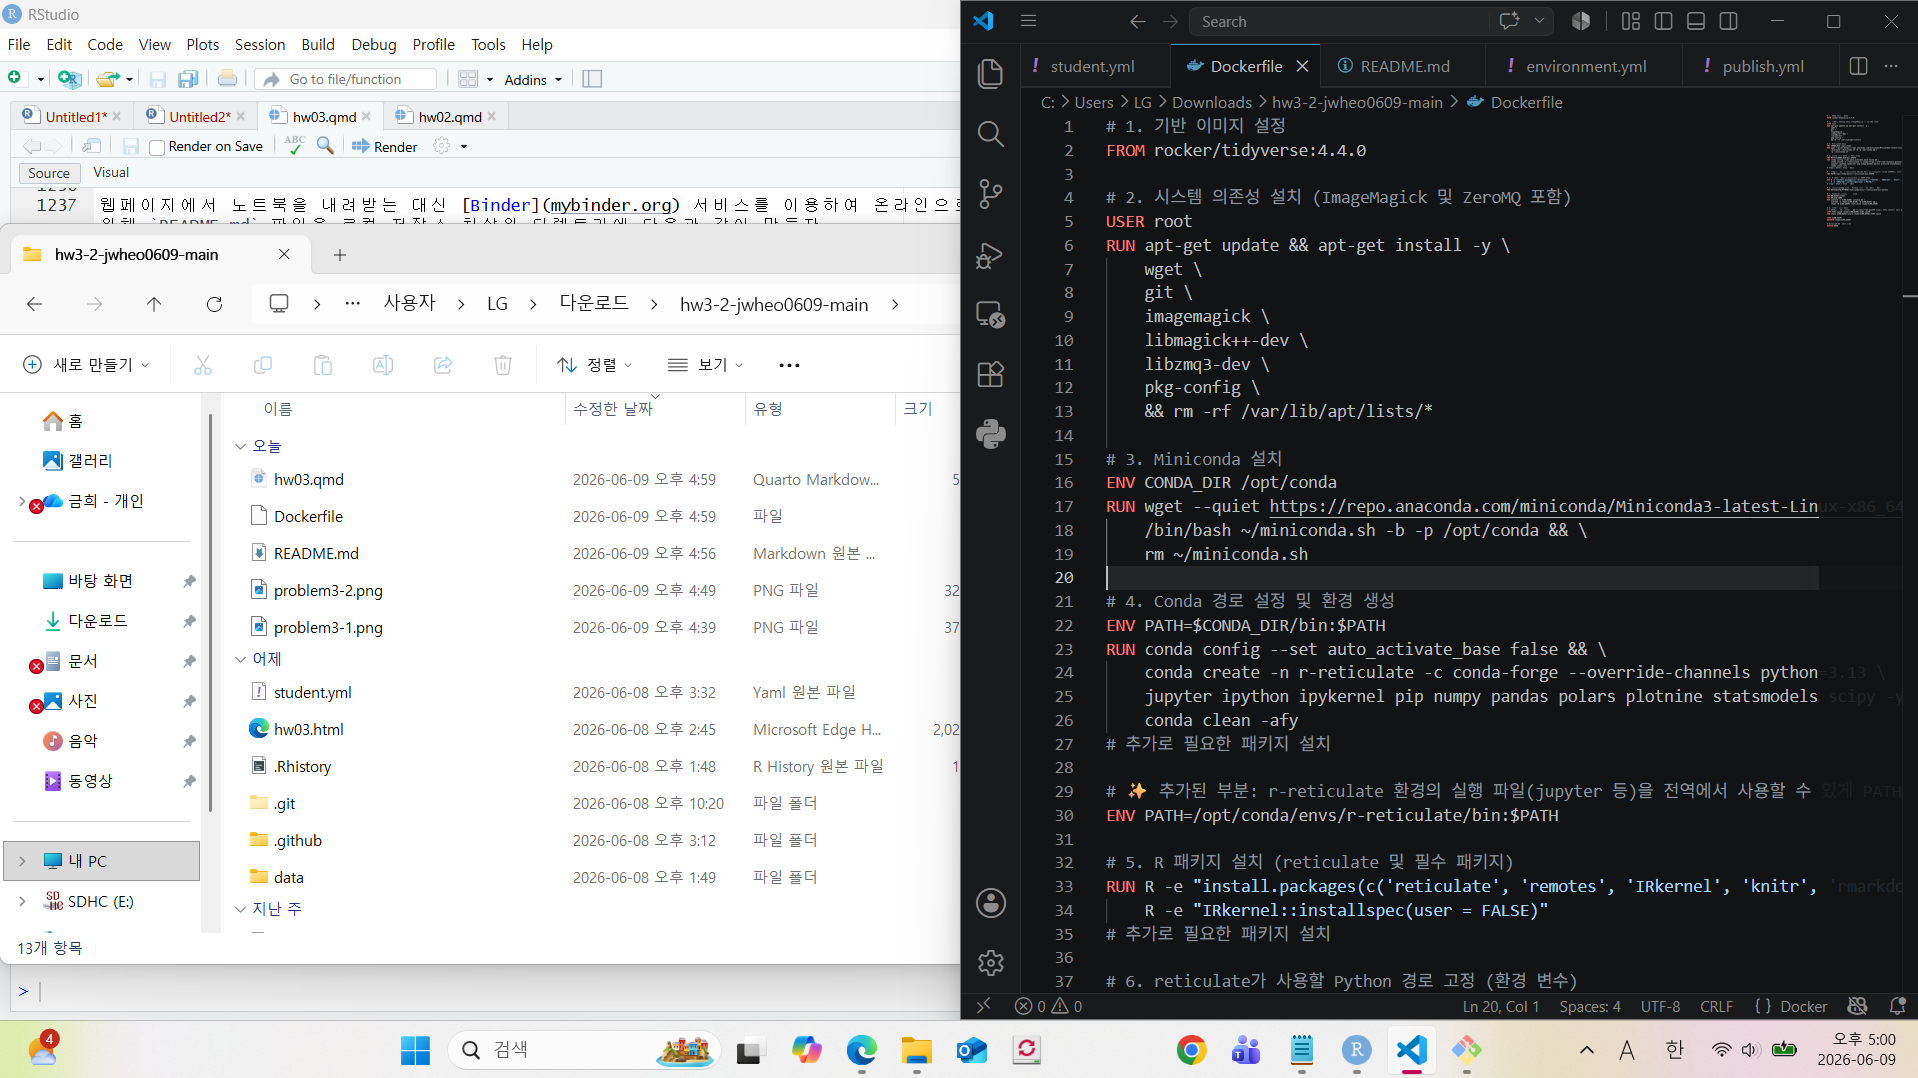

## 문제 3-2. GitHub Actions 워크플로우 수정

숙제 2에서 만들었던 `publish.yml`을 수정하여 기존의 배포 단계 끝에
Docker 컨테이너 이미지를 빌드하고 Github Container Registry (GHCR)에
푸시하는 단계를 추가한다.

In [ ]:
# ... (기존 Quarto Render 단계 이후)

      - name: Log in to GitHub Container Registry
        uses: docker/login-action@v3
        with:
          registry: ghcr.io
          username: ${{ github.actor }}
          password: ${{ secrets.GITHUB_TOKEN }}

      - name: Build and push Docker image
        uses: docker/build-push-action@v5
        with:
          context: .
          push: true
          tags: ghcr.io/${{ github.repository_owner }}/my-r-env:latest

### 답안

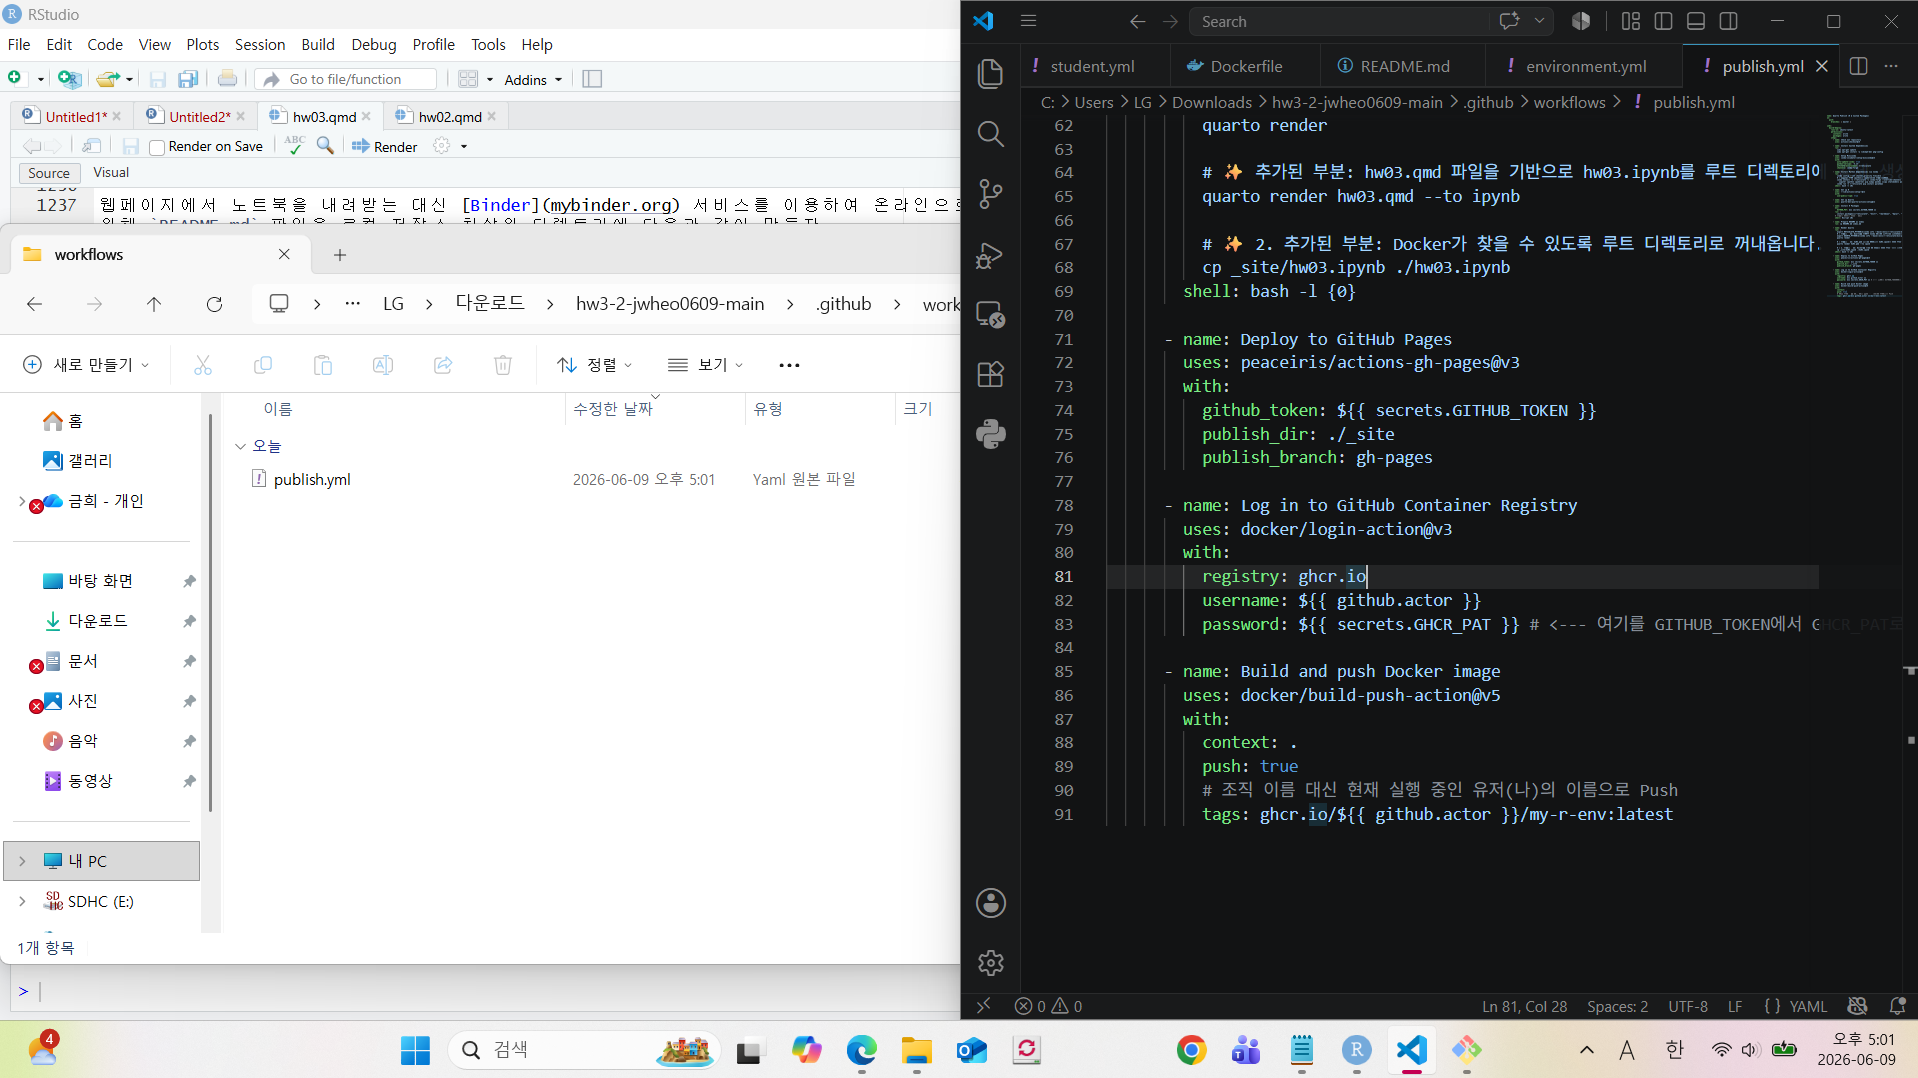

## 문제 3-3. GitHub Pages에 Binder 링크 추가

GitHub Page를 사용하여 저장소를 웹페이지로 활용하는 부분은 숙제 2에서와
같다.

웹페이지에서 노트북을 내려받는 대신 [Binder](mybinder.org) 서비스를
이용하여 온라인으로 노트북을 실행할 수 있도록 위해 `README.md` 파일을
로컬 저장소 최상위 디렉토리에 다음과 같이 만들자.

In [ ]:
# 숙제 3

이름: [아무개]
학번: [나의 학번]

이 숙제의 상세 분석 결과는 아래 링크에서 확인하실 수 있습니다.

* [분석 리포트 (HTML)](./hw03.html) 
* [주피터 노트북 (ipynb)](https://mybinder.org/v2/gh/<유저명>/snu-stat/<repo명>/gh-pages?filepath=hw03.ipynb

여기서 `<유저명>`은 제출자의 GitHub 유저 아이디이며, `<repo명>`은 hw3-로
시작하는 제출자의 repository 이름이다.

작업을 GitHub 원격 저장소로 push한 후 숙제 2 문제 3-3의 3, 4번 과정을
반복하라.

### 답안

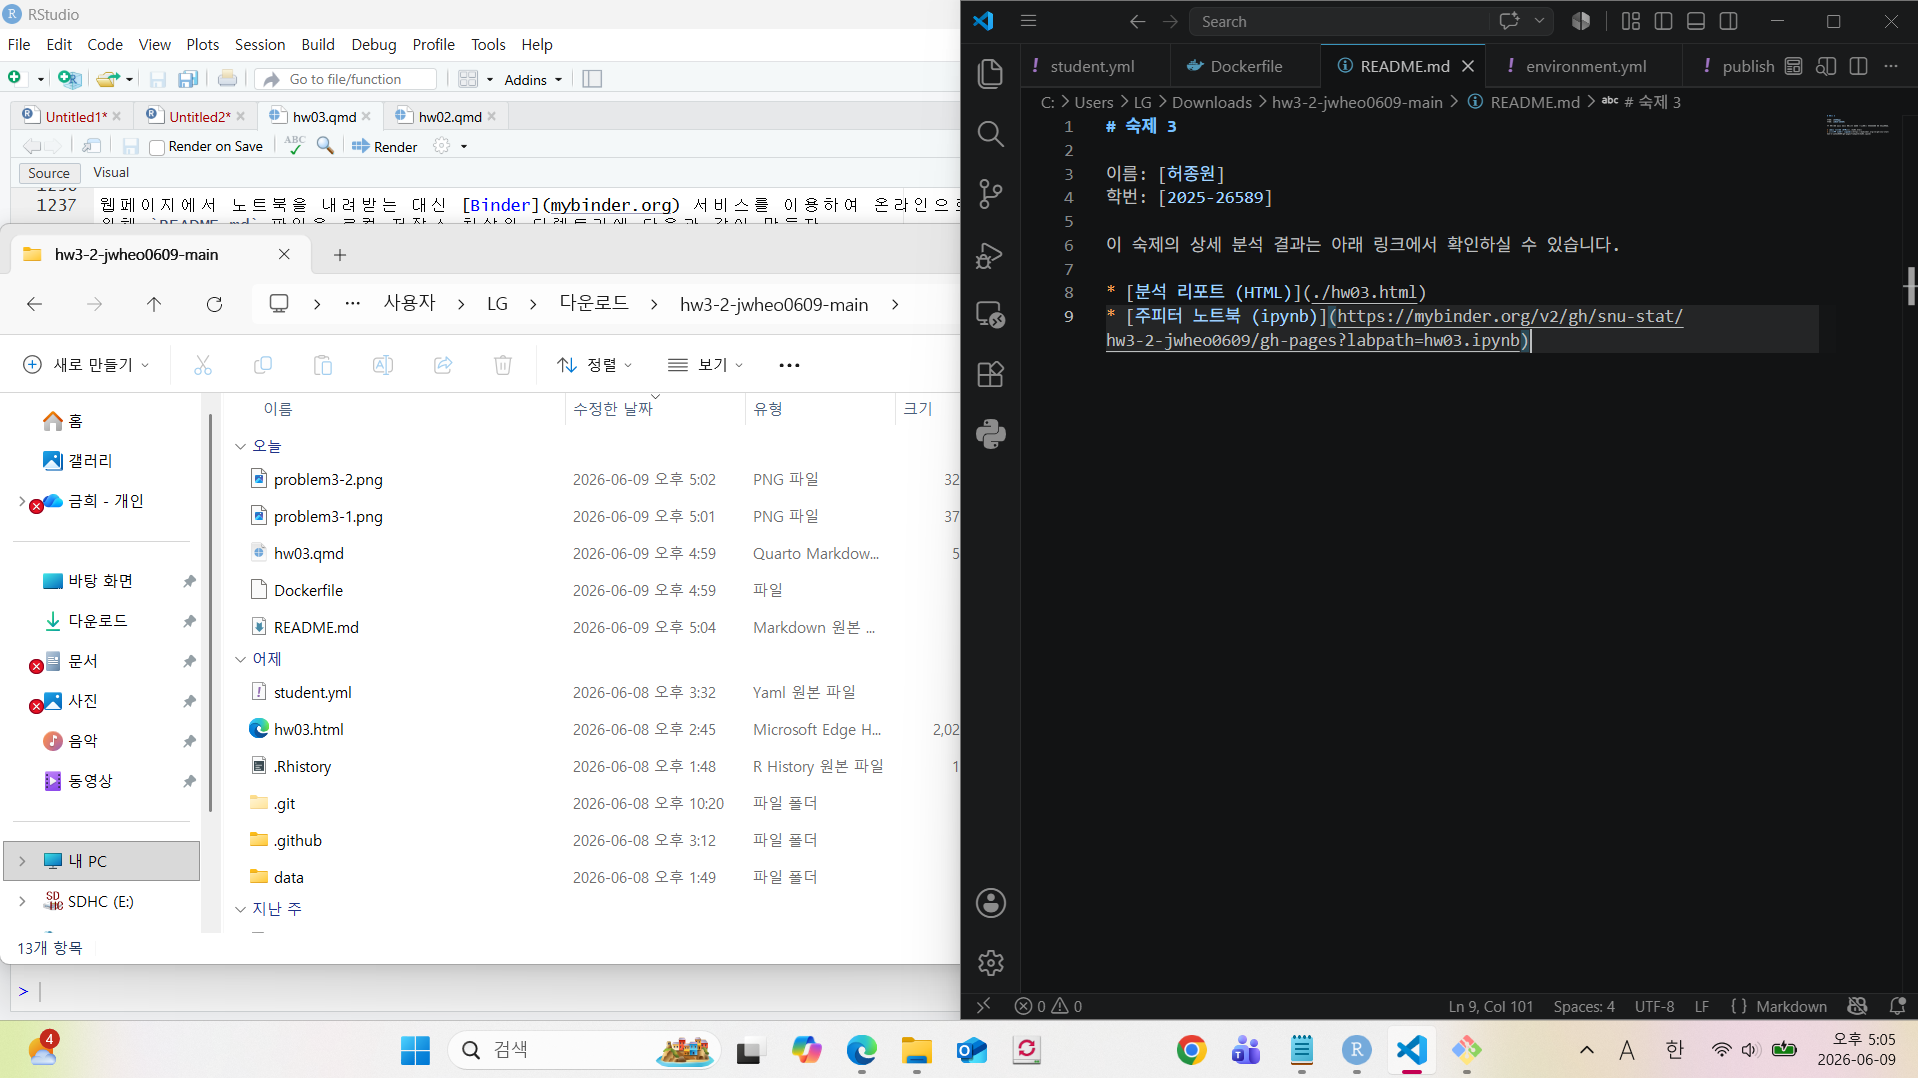